In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
file_path = 'D:\\GitHub\\DataIO\\'
sys.path.append(os.path.dirname(file_path))

from data_io import toleos_den

In [3]:
import orekit_jpype as orekit


orekit.initVM(jvmpath="C://Program Files//Eclipse Adoptium//jdk-17.0.18.8-hotspot//bin//server//jvm.dll",
              additional_classpaths=[r"D:\GitHub\contigo_edr\java_src\target\orekit_utils-1.0.0.jar"])

In [4]:
from orekit_jpype.pyhelpers import setup_orekit_data, download_orekit_data_curdir
#download_orekit_data_curdir()
setup_orekit_data(from_pip_library=False)

In [5]:
import pandas as pd
import numpy as np
import glob
import os
import sys

import matplotlib.pyplot as plt

from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity

# Ephemeris
from contigo.ephemeris.orekit_ephem import OrekitEphem
from contigo.solar_system_ephem import SolarSystemEnvironment

# Forces and acceleration
from contigo.forces.third_body_acc import ThirdBodyEnv
from contigo.forces.grav_pot import EarthPotential
from contigo.forces.srp_orekit import SRPOrekitCB

In [6]:
data_dir = r'D:\data\SatDensities\SWARM\SWB\SP3xCOM' 
fn_pre = 'SW_OPER_SP3BCOM_2__'

sdate = '2018-03-17' 
edate = '2018-03-29'

dt_ran = pd.date_range(sdate,edate,freq='1D')

fn =  []

_ = [fn.extend(glob.glob(os.path.join(data_dir,f'{fn_pre}{dt.strftime("%Y%m%d")}*'))) for dt in dt_ran]


In [7]:
sw_tol, sw_meta, _ = toleos_den.load_toleos(sat='SB',sdate=sdate, edate='2018-03-31')
sw_tol['dens_x_km'] = sw_tol['dens_x']*(1000.**3)

In [10]:
# create a Constellation object from the ESA POD file
# and calculate thirdbody acceleration from ThirdBody
hdf_sc1 = Constellation(state_file=fn, sc_id_input='SWB', tscale_input='GPS',
                    sc_mass=4.31e+02, cr=1.14, srp_area=2.5*2, cd=3.7, drag_area=1.1)


step = 30
id2 = hdf_sc1['SWB'].sc_id[::step]
id2[:] = 'SWB2' 
hdf_sc2 = Constellation(state=hdf_sc1['SWB'].state[::step,:],time= hdf_sc1['SWB'].sc_utc[::step],
                        sc_id_input=hdf_sc1['SWB'].sc_id[::step], tscale_input='UTC',
                        sc_mass=4.31e+02, cr=1.14, srp_area=2.5*2, cd=3.7, drag_area=1.1)

hdf_sc = hdf_sc1+hdf_sc2

In [11]:
# setup the ephemeris provider we want
# and the solar system environement 
# which defines the tolerance for ephemeris cacheing and the bodies we want
# in our solar system
#ephem = SPICEEphem(ephemeris='de440s', frame='ITRF93', observer='EARTH')
ephem = OrekitEphem( )

env = SolarSystemEnvironment(bodies=['SUN','MOON'], tolerance=0.01, provider=ephem, 
                            ephem_time=hdf_sc.sspice_et, 
                            gps_time=hdf_sc.sspice_gps,
                            utc_time=hdf_sc.sc_utc)

In [12]:
# this is a big lmax but this is what 
# we use in the orekit derivation and
# is what we need here to for a comparison
ep = EarthPotential(lmax=40) 
tba_env = ThirdBodyEnv( )
srp = SRPOrekitCB( )

In [13]:
#edr = EDRDensity(constellation=hdf_sc,
#                 solarsys_env=env, 
#                 force_models=[tba_env,srp],
#                 potential_model=ep)

edr = EDRDensity(constellation=hdf_sc,
                 solarsys_env=env, 
                 force_models=[tba_env],
                 potential_model=ep)

In [14]:
acc_con = edr.compute_edr()
den_con = edr.compute_denom()

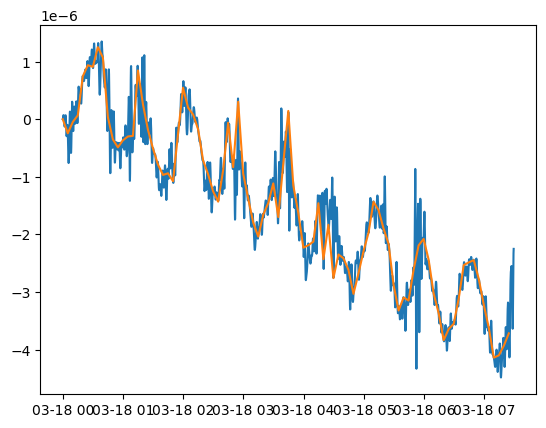

In [15]:
fig, ax = plt.subplots(1,1)

orb=5
npts = int(5*90*60/10)
npts2 = int(npts/step)

ax.plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
ax.plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])

In [16]:
edr_sw = pd.Series(acc_con['SWB']['edr']).rolling(90, min_periods=1, center=True).mean().to_numpy()

<Axes: xlabel='DateTime'>

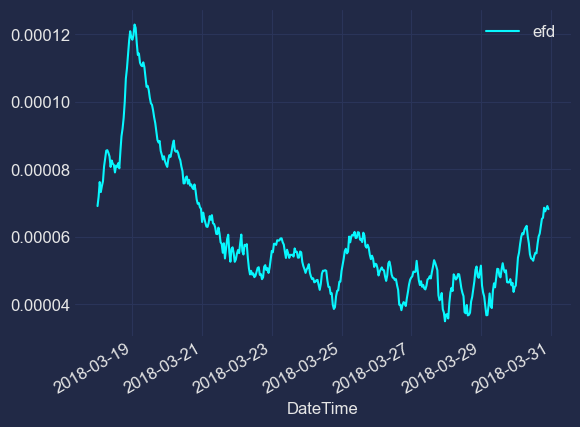

In [148]:
sat_der='SWB2'
step = pd.Timedelta(minutes=45)
s = edr.constellation[sat_der].sc_utc[0]
e = s+step

delta_edr = []
delta_den = []
d_dt = []

edr_sw = pd.Series(acc_con[sat_der]['edr']).rolling(20, min_periods=1, center=True).mean().to_numpy()

while e < edr.constellation.sc_utc.max():
    gd_ind = np.where((edr.constellation[sat_der].sc_utc >= s) & (edr.constellation[sat_der].sc_utc < e))

    id_min = gd_ind[0].min() 
    id_max = gd_ind[0].max()

    delta_edr.append(edr_sw[id_max]-edr_sw[id_min])
    delta_den.append(den_con[sat_der][id_max] - den_con[sat_der][id_min])
    d_dt.append(s)

    s = s+step
    e = e+step

delta_edr = np.array(delta_edr)
delta_den = np.array(delta_den)
d_dt = np.array(d_dt)
efd = -2*delta_edr/delta_den

den_df = pd.DataFrame({'DateTime':d_dt, 'd_edr':delta_edr,'d_den':delta_den})
den_df['efd'] = -2*den_df['d_edr'].rolling(10, min_periods=1, center=True).mean()/den_df['d_den']

den_df['DateTime'] = den_df['DateTime'].dt.tz_localize(None)
den_df.plot(x='DateTime',y='efd')

In [18]:
col = ['dens_x_km','DateTime']

sw_state = pd.DataFrame({'DateTime':pd.to_datetime(hdf_sc['SWB'].sc_utc)})
sw_state['DateTime'] = sw_state['DateTime'].dt.tz_localize(None)
sw_state['vx'] = hdf_sc['SWB'].state_ecef[:,3]
sw_state['vy'] = hdf_sc['SWB'].state_ecef[:,4]
sw_state['vz'] = hdf_sc['SWB'].state_ecef[:,5]
sw_state['v'] = np.linalg.norm(hdf_sc['SWB'].state_ecef[:,3:],axis=1)

sw_comb = pd.merge_asof(sw_tol[col],sw_state, left_on='DateTime', right_on='DateTime',
                         tolerance=pd.Timedelta('15s')).dropna()

In [19]:
from scipy.integrate import simpson 

In [20]:
step = pd.Timedelta(minutes=90)
s = sw_comb['DateTime'].min()
e = s+step

tol_efd = []
tol_dt = []

while e < sw_comb['DateTime'].max():
    gd_ind = (sw_comb['DateTime'] >= s) & (sw_comb['DateTime'] < e)

    v = sw_comb.loc[gd_ind,'v'].to_numpy()
    d = sw_comb.loc[gd_ind,'dens_x_km'].to_numpy()

    x = sw_comb.loc[gd_ind,'DateTime']
    x = (x-x.min()).dt.total_seconds().to_numpy()
    
    nume = simpson(d*v**3,x)
    deno = simpson(v**3,x)

    tol_efd.append(nume/deno)
    tol_dt.append(s)

    s = s+step
    e = e+step

tol_efd = pd.DataFrame({'efd':tol_efd, 'DateTime':tol_dt})

In [21]:
import mplcyberpunk
plt.style.use("cyberpunk")

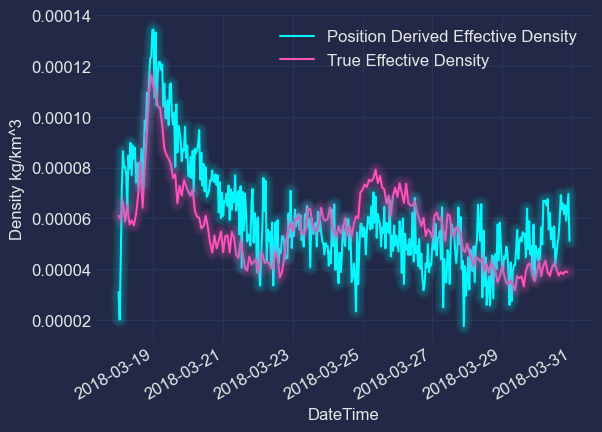

In [22]:
plt.rcParams.update({'font.size': 12})
ax = den_df.plot(x='DateTime',y='efd', label='Position Derived Effective Density',
                 ylabel='Density kg/km^3')
tol_efd.plot(x='DateTime',y='efd',ax=ax, label='True Effective Density')
mplcyberpunk.make_lines_glow(ax)


In [23]:
tol_efd = pd.merge_asof(tol_efd,den_df,left_on='DateTime',right_on='DateTime',
                        tolerance=pd.Timedelta('5m'))

In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import r2_score

print(mean_absolute_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(median_absolute_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(mean_absolute_percentage_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(r2_score(tol_efd['efd_y'],tol_efd['efd_x']))

0.013895840496191662
0.013385578095727657
0.25407532645652975
0.3812413835971984


In [25]:
import cdflib
def sw_scdyn(sat: str='B', 
                sdate='2010-01-01',
                nd: int=1,
                edate=None,
                local_dir='D:/data/SatDensities/SWARM/',
                full=False):
    
    # check to make sure appropriate satellites are loaded
    sat_opts = ['A', 'B', 'C']
    sat = sat.upper()
    if sat not in sat_opts: 
        raise ValueError("Invalid sat type. Expected one of: %s" % sat_opts)
    
    freq='D'
    # create a list of dates for
    # files to retrieved
    if edate is not None:
        d_ser = pd.date_range(start=pd.to_datetime(sdate), 
                              end=pd.to_datetime(edate),
                              freq=freq)
    else:
        d_ser = pd.date_range(start=sdate, periods=nd, freq=freq)
        edate = d_ser.max()
    
    fx = [
        os.path.join(local_dir, f'SW{sat}','xDYN',
                     f'SW*_{x.year}{x.month:02}{x.day:02}T*.cdf') 
        for x in d_ser
        ]
    
    fn = [glob.glob(x)[0] for x in fx if len(glob.glob(x)) > 0]
    
    a_head = []
    m_sc = []

    cdf_dat = {}
    cdf_att = {}

    for fi in fn:
        with cdflib.CDF(fi) as cdf_file:
            a_head.extend(cdf_file.varget('A_head'))
            m_sc.extend(cdf_file.varget('m_SC')) 
            if full:
                # loop through and save the variables
                for var in cdf_file.cdf_info().zVariables:
                    # Varibles
                    if var in cdf_dat:
                        cdf_dat[var].extend(cdf_file.varget(var))
                    else:
                        cdf_dat[var] = []
                        cdf_dat[var].extend(cdf_file.varget(var))
                        cdf_att[f'{var}_att'] = cdf_file.varattsget(var) 
                    


    if full:
        cdf_dat['DateTime'] = cdflib.epochs.CDFepoch.to_datetime(cdf_dat['Timestamp'])
        return cdf_dat, cdf_att
    else:
        return np.array(a_head), np.array(m_sc)

In [45]:
dat, att = sw_scdyn(sdate=sdate,edate='2018-03-31', full=True)

In [109]:
srp_sw = np.linalg.norm(dat['a_Sun'],axis=1)


In [137]:
srp_cont = SRPOrekitCB().acceleration(constellation=edr.constellation, solarsys_env=env)

In [138]:
srp_acc = np.linalg.norm(srp_cont['SWB'],axis=1)

In [129]:
sat = hdf_sc['SWB']

In [32]:
edr_r = 0.5*sat.cd_arr*sat.drag_area_arr*(np.linalg.norm(sat.state_ecef[:,3:],axis=1)*1000)**3/sat.sc_mass_arr

In [ ]:

pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None).astype('datetime64[ns]')

DatetimeIndex(['2018-03-17 23:59:42', '2018-03-17 23:59:52',
               '2018-03-18 00:00:02', '2018-03-18 00:00:12',
               '2018-03-18 00:00:22', '2018-03-18 00:00:32',
               '2018-03-18 00:00:42', '2018-03-18 00:00:52',
               '2018-03-18 00:01:02', '2018-03-18 00:01:12',
               ...
               '2018-03-30 23:58:02', '2018-03-30 23:58:12',
               '2018-03-30 23:58:22', '2018-03-30 23:58:32',
               '2018-03-30 23:58:42', '2018-03-30 23:58:52',
               '2018-03-30 23:59:02', '2018-03-30 23:59:12',
               '2018-03-30 23:59:22', '2018-03-30 23:59:32'],
              dtype='datetime64[ns]', length=112320, freq=None)

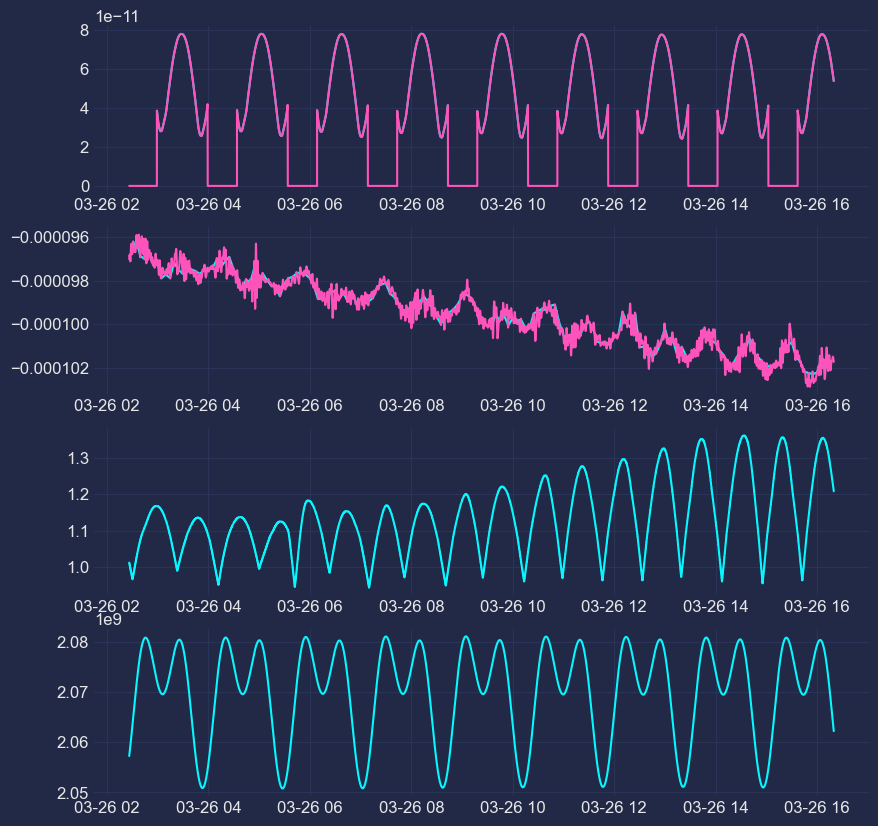

In [141]:
sc = slice(70000,75000)
s_st = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].min().replace(tzinfo=None) )
s_en = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].max().replace(tzinfo=None) )

#ax.plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
#ax.plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])

gd_swb = np.where((pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) < s_en)) 
gd_swb2 = np.where((pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) < s_en)) 
sw_gd = np.where((dat['DateTime'] > s_st) & (dat['DateTime'] < s_en))

fig, ax = plt.subplots(4,1, figsize=(10,10))
ax[0].plot(hdf_sc['SWB'].sc_utc[sc],srp_acc[sc])
ax[0].plot(dat['DateTime'][sw_gd],srp_sw[sw_gd]/1000.)

ax[1].plot(edr.constellation['SWB2'].sc_utc[gd_swb2],acc_con['SWB2']['edr'][gd_swb2])
ax[1].plot(edr.constellation['SWB'].sc_utc[gd_swb],acc_con['SWB']['edr'][gd_swb])

ax[2].plot(dat['DateTime'][sw_gd],np.linalg.norm(dat['A_head'],axis=1)[sw_gd])

ax[3].plot(hdf_sc['SWB'].sc_utc[sc],edr_r[sc])

In [ ]:
print(dat['DateTime'][0:5])
print(edr.constellation['SWB'].sc_utc[0:5])

['2018-03-17T00:00:00.756000000' '2018-03-17T00:00:01.756000000'
 '2018-03-17T00:00:02.756000000' '2018-03-17T00:00:03.756000000'
 '2018-03-17T00:00:04.756000000']
[datetime.datetime(2018, 3, 17, 23, 59, 42, tzinfo=datetime.timezone.utc)
 datetime.datetime(2018, 3, 17, 23, 59, 52, tzinfo=datetime.timezone.utc)
 datetime.datetime(2018, 3, 18, 0, 0, 2, tzinfo=datetime.timezone.utc)
 datetime.datetime(2018, 3, 18, 0, 0, 12, tzinfo=datetime.timezone.utc)
 datetime.datetime(2018, 3, 18, 0, 0, 22, tzinfo=datetime.timezone.utc)]


In [114]:
kin_df = pd.DataFrame({'DateTime':pd.to_datetime(dat['DateTime']),
                       'DragArea':np.linalg.norm(dat['A_head'],axis=1),
                       'SRP':srp_sw/1000.})
sc_df = pd.DataFrame({'DateTime':pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None)}).astype('datetime64[ns]')
sc_df['SRP_CB'] = srp_acc 

In [115]:
sc_df = pd.merge_asof(sc_df,kin_df, left_on='DateTime',right_on='DateTime', 
                       tolerance=pd.Timedelta('5s'))

In [116]:
print(sc_df.tail(3))
print(kin_df.tail(3))

                  DateTime        SRP_CB  DragArea           SRP
112317 2018-03-30 23:59:12  6.044953e-11  1.010815  3.961611e-11
112318 2018-03-30 23:59:22  6.044958e-11  1.007681  3.996039e-11
112319 2018-03-30 23:59:32  6.044963e-11  1.005555  4.030022e-11
                       DateTime  DragArea           SRP
1295977 2018-03-31 23:59:57.757  1.310497  7.439233e-11
1295978 2018-03-31 23:59:58.756  1.310497  7.438745e-11
1295979 2018-03-31 23:59:59.756  1.310497  7.438328e-11


In [131]:
sc_df['SRP_ratio']=sc_df['SRP']/sc_df['SRP_CB']

In [126]:
edr.constellation['SWB'].srp_area_arr

array([7.1707672 , 7.29098714, 7.41503016, ..., 7.62941194, 7.56368673,
       7.49991208], shape=(112320,))

In [134]:
sc_df['SRP_ratio'].to_numpy()

array([0.69727546, 0.68577819, 0.67430609, ..., 0.6553585 , 0.66105329,
       0.66667448], shape=(112320,))

In [135]:
hdf_sc1['SWB'].srp_area_arr

array([5., 5., 5., ..., 5., 5., 5.], shape=(112320,))

In [136]:
edr.constellation['SWB'].srp_area_arr = sc_df['SRP_ratio'].to_numpy() * hdf_sc1['SWB'].srp_area_arr

In [52]:
edr.constellation['SWB'].drag_area_arr = sc_df['DragArea'].to_numpy()           

In [55]:
edr.constellation['SWB'].drag_area_arr[-1]

np.float64(1.0055550705953404)

In [140]:
acc_con = edr.compute_edr()
den_con = edr.compute_denom()

In [63]:
den_con

{'SWB': array([0.00000000e+00, 4.16731049e-05, 8.33458362e-05, ...,
        4.82446894e+00, 4.82450693e+00, 4.82454482e+00], shape=(112320,)),
 'SWB2': array([0.00000000e+00, 1.23223947e-03, 2.46293202e-03, ...,
        4.64609886e+00, 4.64734309e+00, 4.64858535e+00], shape=(3744,))}

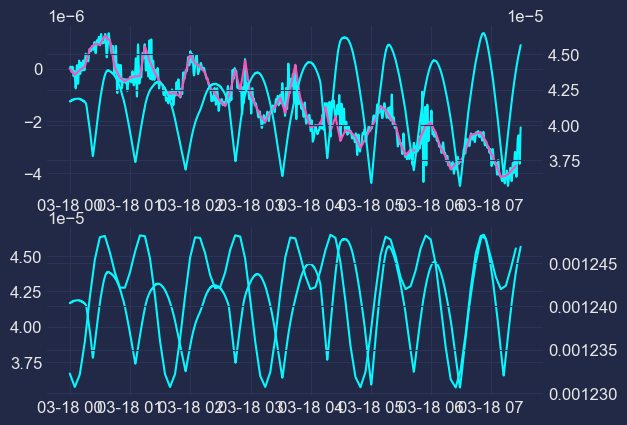

In [100]:
fig, ax = plt.subplots(2,1)

orb=5
npts = int(orb*90*60/10)
npts2 = int(npts/30)

ax[0].plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
ax[0].plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])
ax_t0 = ax[0].twinx()
ax_t0.plot(edr.constellation['SWB'].sc_utc[0:npts],den_con['SWB'][1:npts+1]-den_con['SWB'][0:npts]-den_con['SWB'][0])


ax[1].plot(edr.constellation['SWB'].sc_utc[0:npts],den_con['SWB'][1:npts+1]-den_con['SWB'][0:npts]-den_con['SWB'][0])
ax_t = ax[1].twinx()
ax_t.plot(edr.constellation['SWB2'].sc_utc[0:npts2],den_con['SWB2'][1:npts2+1]-den_con['SWB2'][0:npts2]-den_con['SWB2'][0])

In [69]:
sc = edr.constellation['SWB']

In [70]:
b=sc.cd_arr*(sc.drag_area_arr/1000.**2)/sc.sc_mass_arr

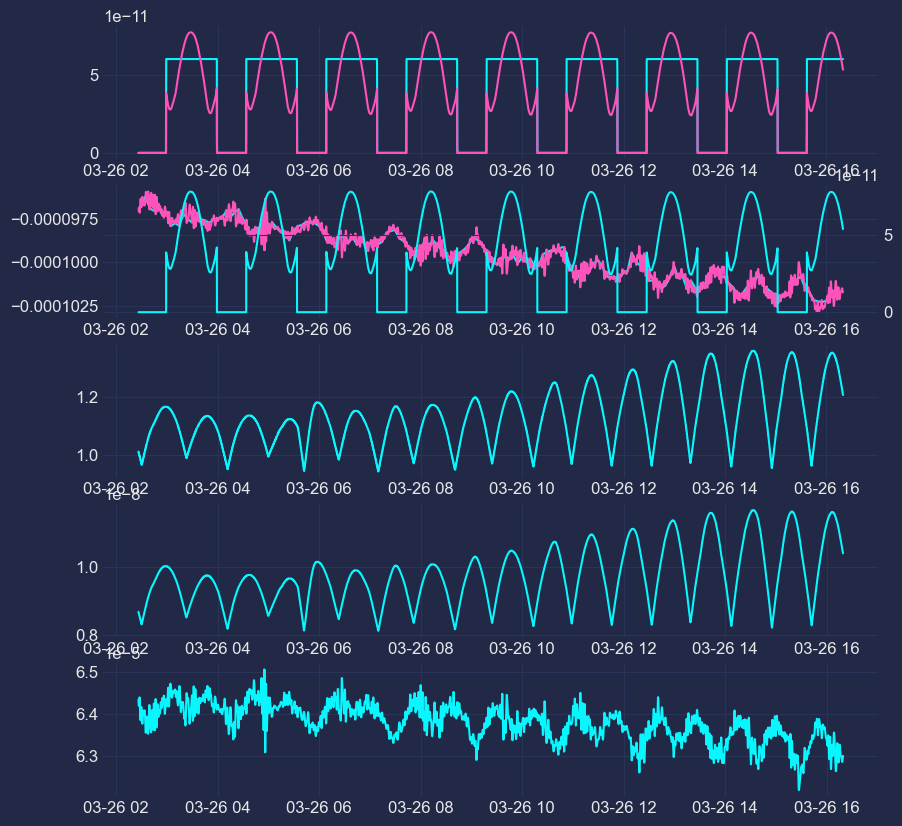

In [104]:
sc = slice(70000,75000)
s_st = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].min().replace(tzinfo=None) )
s_en = pd.to_datetime(hdf_sc['SWB'].sc_utc[sc].max().replace(tzinfo=None) )

#ax.plot(edr.constellation['SWB'].sc_utc[0:npts],acc_con['SWB']['edr'][0:npts])
#ax.plot(edr.constellation['SWB2'].sc_utc[0:npts2],acc_con['SWB2']['edr'][0:npts2])

gd_swb = np.where((pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB'].sc_utc).tz_localize(None) < s_en)) 
gd_swb2 = np.where((pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) > s_st) & 
                  (pd.to_datetime(edr.constellation['SWB2'].sc_utc).tz_localize(None) < s_en)) 
sw_gd = np.where((dat['DateTime'] > s_st) & (dat['DateTime'] < s_en))

fig, ax = plt.subplots(5,1, figsize=(10,10))
ax[0].plot(hdf_sc['SWB'].sc_utc[sc],srp_acc[sc])
ax[0].plot(dat['DateTime'][sw_gd],srp_sw[sw_gd]/1000.)

ax[1].plot(edr.constellation['SWB2'].sc_utc[gd_swb2],acc_con['SWB2']['edr'][gd_swb2])
ax[1].plot(edr.constellation['SWB'].sc_utc[gd_swb],acc_con['SWB']['edr'][gd_swb])
axt = ax[1].twinx()
axt.plot(dat['DateTime'][sw_gd],srp_sw[sw_gd]/1000.)

ax[2].plot(dat['DateTime'][sw_gd],np.linalg.norm(dat['A_head'],axis=1)[sw_gd])

ax[3].plot(hdf_sc['SWB'].sc_utc[gd_swb],b[gd_swb])

ax[4].plot(hdf_sc['SWB'].sc_utc[gd_swb],-2*acc_con['SWB']['edr'][gd_swb]/den_con['SWB'][gd_swb])